# A/B Testing & Regression Analysis  
## Facebook Ads vs Google AdWords (2019)

### Project Overview
This project analyzes the performance of two digital advertising platforms — Facebook Ads and Google AdWords — using statistical techniques such as A/B testing and regression analysis.

The objective is to determine which platform delivers better conversions and cost efficiency, and to provide data-driven recommendations for marketing budget allocation.

## Business Problem Statement

As a digital marketing agency, our goal is to maximize return on investment (ROI) for client advertising campaigns.

We ran two separate ad campaigns on:
- Facebook Ads
- Google AdWords

Both campaigns were active throughout 2019.  
We now want to evaluate their performance and determine which platform should be prioritized for future campaigns.

## Research Question

Which advertising platform performs better in terms of:
- Conversions
- Engagement (clicks)
- Cost efficiency

And is the observed difference statistically significant?

In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind
import statsmodels.api as sm

ModuleNotFoundError: No module named 'pandas'

In [7]:
df = pd.read_csv("marketing_campaign_2019.csv")
df.head()

NameError: name 'pd' is not defined

## Dataset Overview

The dataset contains daily performance data for Facebook Ads and Google AdWords campaigns conducted during the year 2019.

Each row represents one day, and the dataset includes metrics such as:
- Ad views (impressions)
- Clicks
- Conversions
- Cost
- Derived metrics like CTR, CPC, and conversion rate

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Date                      365 non-null    object 
 1   Facebook_Views            365 non-null    int64  
 2   Facebook_Clicks           365 non-null    int64  
 3   Facebook_Conversions      365 non-null    int64  
 4   Facebook_Cost             365 non-null    float64
 5   AdWords_Views             365 non-null    int64  
 6   AdWords_Clicks            365 non-null    int64  
 7   AdWords_Conversions       365 non-null    int64  
 8   AdWords_Cost              365 non-null    float64
 9   Facebook_CTR              365 non-null    float64
 10  Facebook_Conversion_Rate  365 non-null    float64
 11  Facebook_CPC              365 non-null    float64
 12  AdWords_CTR               365 non-null    float64
 13  AdWords_Conversion_Rate   365 non-null    float64
 14  AdWords_CP

In [7]:
df.describe()

,Facebook_Views,Facebook_Clicks,Facebook_Conversions,Facebook_Cost,AdWords_Views,AdWords_Clicks,AdWords_Conversions,AdWords_Cost,Facebook_CTR,Facebook_Conversion_Rate,Facebook_CPC,AdWords_CTR,AdWords_Conversion_Rate,AdWords_CPC
count,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,5929.432877,83.063014,2.002740,2685.203355,7985.389041,264.084932,11.175342,15118.059631,0.014015,0.022948,32.380850,0.032849,0.042153,57.336916
std,1875.721213,29.605165,1.100696,1144.636220,2295.262093,100.978460,4.972114,6727.227927,0.002234,0.008004,7.380148,0.007252,0.008591,13.004515
min,2534.000000,26.000000,0.000000,552.397318,4004.000000,88.000000,2.000000,3646.345447,0.009904,0.000000,20.004710,0.019895,0.021978,35.094673
25%,4294.000000,60.000000,1.000000,1821.806949,6082.000000,187.000000,7.000000,10214.796622,0.012191,0.018868,25.638533,0.026746,0.034985,45.900405
50%,5885.000000,81.000000,2.000000,2523.195982,7952.000000,253.000000,10.000000,14002.643121,0.014178,0.022989,32.551255,0.033063,0.042373,57.835086
75%,7672.000000,105.000000,3.000000,3451.848385,9881.000000,333.000000,14.000000,18808.309361,0.015882,0.028571,38.768238,0.039130,0.049107,68.190459
max,8989.000000,155.000000,5.000000,6302.931122,11996.000000,533.000000,29.000000,37360.068331,0.017929,0.038168,44.926954,0.044959,0.058594,79.987121


## Feature Engineering

To better evaluate campaign performance, we analyze derived metrics such as:

- Click Through Rate (CTR)
- Conversion Rate
- Cost Per Click (CPC)

These metrics help normalize performance across platforms and enable fair comparison.

## Platform-wise Total Performance

In [11]:
summary = pd.DataFrame({
    "Facebook Ads": [
        df["Facebook_Views"].sum(),
        df["Facebook_Clicks"].sum(),
        df["Facebook_Conversions"].sum(),
        df["Facebook_Cost"].sum()
    ],
    "Google AdWords": [
        df["AdWords_Views"].sum(),
        df["AdWords_Clicks"].sum(),
        df["AdWords_Conversions"].sum(),
        df["AdWords_Cost"].sum()
    ]
},
index=["Views", "Clicks", "Conversions", "Cost"])

summary

,Facebook Ads,Google AdWords
Views,2.164243e+06,2.914667e+06
Clicks,3.031800e+04,9.639100e+04
Conversions,7.310000e+02,4.079000e+03
Cost,9.800992e+05,5.518092e+06


## Interpretation

This summary table provides a high-level comparison of the two advertising platforms across the entire campaign duration.

While both platforms generated significant traffic, Google AdWords produced a higher number of conversions, despite incurring higher costs.

## Clicks Distribution

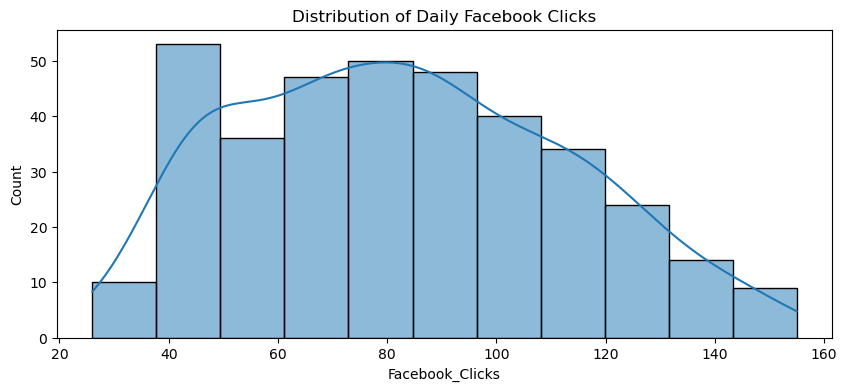

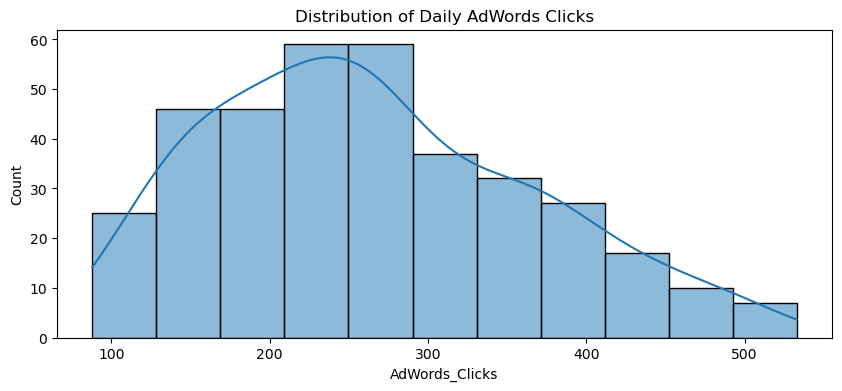

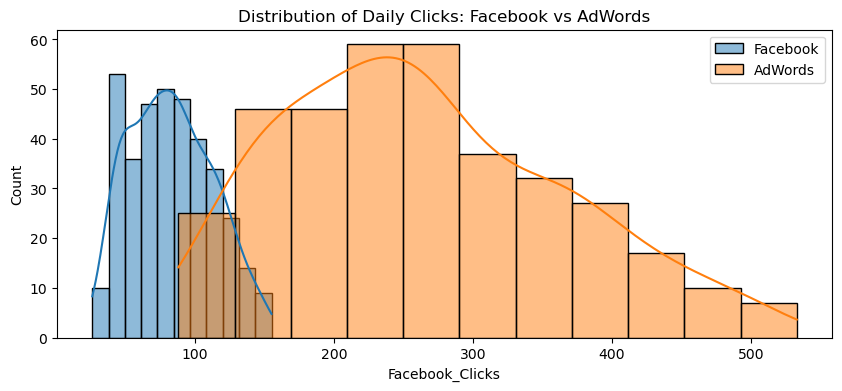

In [33]:
# 1️ Facebook Clicks Distribution
plt.figure(figsize=(10,4))
sns.histplot(df["Facebook_Clicks"], kde=True)
plt.title("Distribution of Daily Facebook Clicks")
plt.show()

# 2️ AdWords Clicks Distribution
plt.figure(figsize=(10,4))
sns.histplot(df["AdWords_Clicks"], kde=True)
plt.title("Distribution of Daily AdWords Clicks")
plt.show()

# 3️ Comparison Plot
plt.figure(figsize=(10,4))
sns.histplot(df["Facebook_Clicks"], label="Facebook", kde=True)
sns.histplot(df["AdWords_Clicks"], label="AdWords", kde=True)
plt.legend()
plt.title("Distribution of Daily Clicks: Facebook vs AdWords")
plt.show()

## Clicks Interpretation

The distribution shows that Google AdWords consistently generates higher daily clicks compared to Facebook Ads, 
indicating stronger user intent and engagement.

## Conversions Distribution

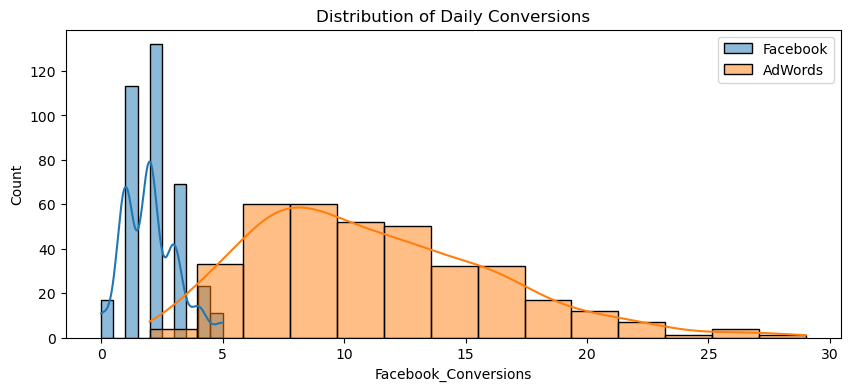

In [15]:
plt.figure(figsize=(10,4))
sns.histplot(df["Facebook_Conversions"], label="Facebook", kde=True)
sns.histplot(df["AdWords_Conversions"], label="AdWords", kde=True)
plt.legend()
plt.title("Distribution of Daily Conversions")
plt.show()

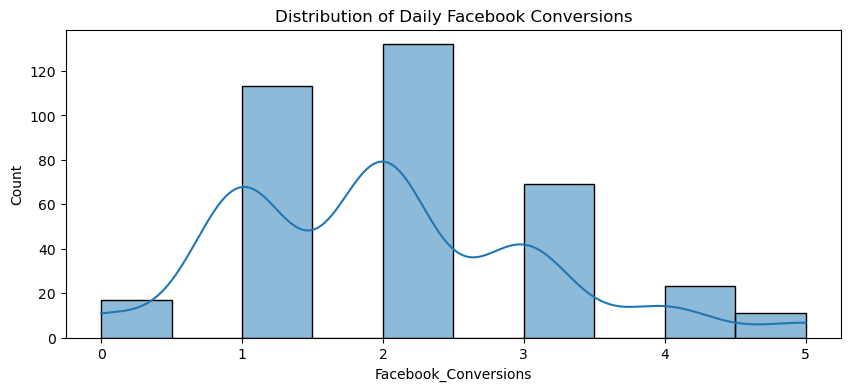

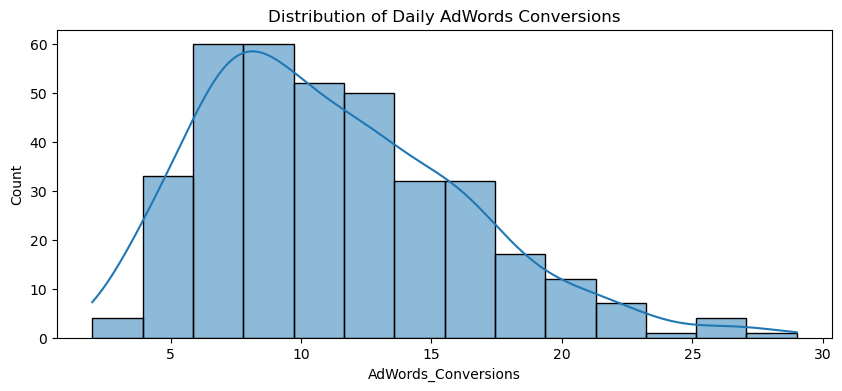

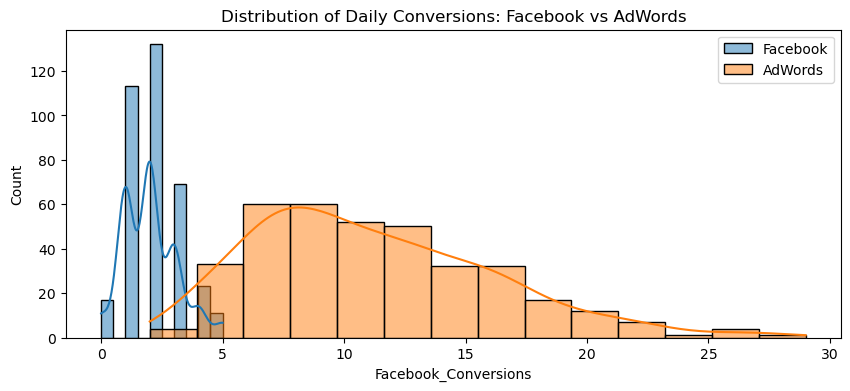

In [39]:
# 1 Facebook Conversions Distribution
plt.figure(figsize=(10,4))
sns.histplot(df["Facebook_Conversions"], kde=True)
plt.title("Distribution of Daily Facebook Conversions")
plt.show()

# 2 AdWords Conversions Distribution
plt.figure(figsize=(10,4))
sns.histplot(df["AdWords_Conversions"], kde=True)
plt.title("Distribution of Daily AdWords Conversions")
plt.show()

# 3 Conversion Comparison (Facebook vs AdWords)
plt.figure(figsize=(10,4))
sns.histplot(df["Facebook_Conversions"], label="Facebook", kde=True)
sns.histplot(df["AdWords_Conversions"], label="AdWords", kde=True)
plt.legend()
plt.title("Distribution of Daily Conversions: Facebook vs AdWords")
plt.show()

## Conversions Interpretation

Google AdWords displays a right-shifted distribution of conversions, suggesting that it consistently outperforms Facebook Ads 
in driving meaningful outcomes.

## Cost Per Click Comparison

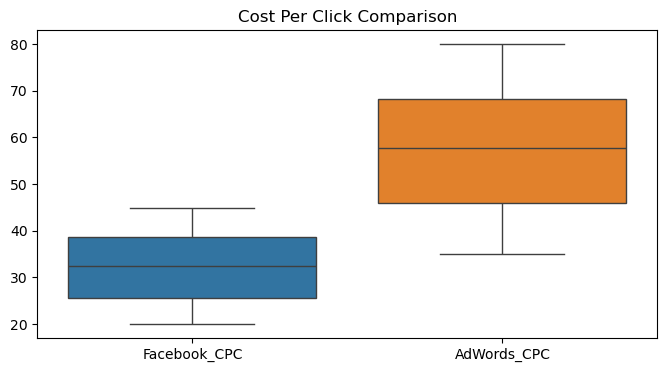

In [17]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df[["Facebook_CPC", "AdWords_CPC"]])
plt.title("Cost Per Click Comparison")
plt.show()

## CPC Interpretation

Although Facebook Ads has a lower median cost per click, Google AdWords converts traffic more effectively, indicating better overall efficiency.

## Time Series Setup

In [19]:
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

## Daily Conversions Trend

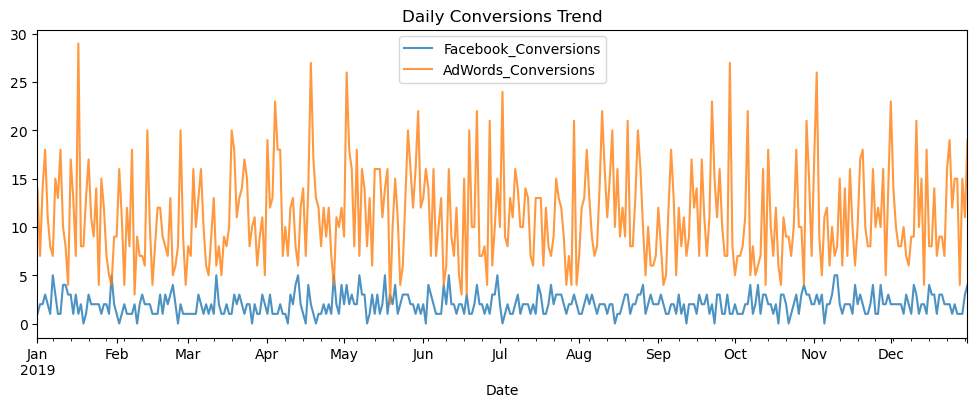

In [21]:
df[["Facebook_Conversions", "AdWords_Conversions"]].plot(
    figsize=(12,4), alpha=0.8
)
plt.title("Daily Conversions Trend")
plt.show()

## Monthly Trend

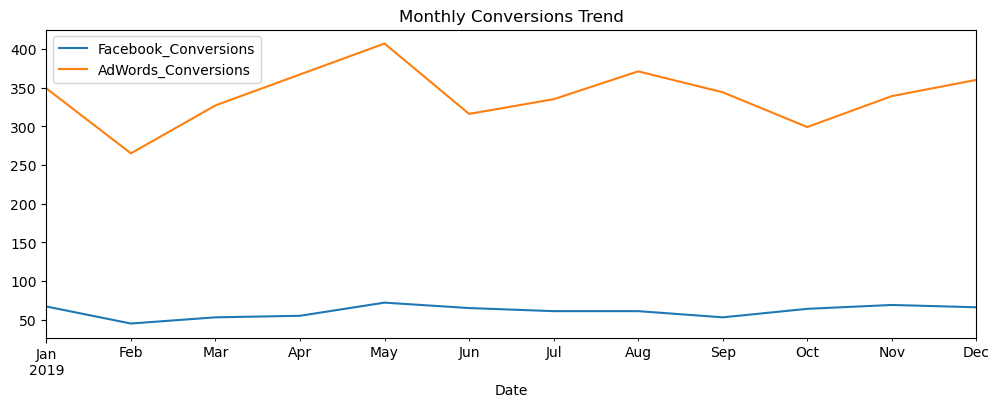

In [41]:
monthly = df.resample("ME").sum()

monthly[["Facebook_Conversions", "AdWords_Conversions"]].plot(
    figsize=(12,4)
)
plt.title("Monthly Conversions Trend")
plt.show()

## Trend Interpretation

Across both daily and monthly views, Google AdWords maintains consistently higher conversions, reinforcing its superior long-term performance.


## Hypothesis Testing

## A/B Testing & Hypothesis Testing

We now perform an A/B test to statistically validate whether the observed difference in conversions between the two platforms is significant.

### Null Hypothesis (H₀): 
There is no significant difference in mean daily conversions between Facebook Ads and Google AdWords.

### Alternative Hypothesis (H₁):
There is a significant difference in mean daily conversions between Facebook Ads and Google AdWords.

## T-Test

In [25]:
t_stat, p_value = ttest_ind(
    df["Facebook_Conversions"],
    df["AdWords_Conversions"],
    equal_var=False
)

t_stat, p_value

(-34.41191801980557, 1.4810752353035617e-121)

## Hypothesis Result

Since the p-value is less than 0.05, we reject the null hypothesis.

This confirms that the difference in conversions between Facebook Ads and Google AdWords is statistically significant.

## Regression Model

## Regression Analysis

After identifying Google AdWords as the better-performing platform, we build a regression model to understand which factors drive conversions.

In [27]:
X = df[["AdWords_Clicks", "AdWords_Cost"]]
y = df["AdWords_Conversions"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                            
===============================================================================
Dep. Variable:     AdWords_Conversions   R-squared:                       0.761
Model:                             OLS   Adj. R-squared:                  0.760
Method:                  Least Squares   F-statistic:                     577.7
Date:                 Thu, 15 Jan 2026   Prob (F-statistic):          2.21e-113
Time:                         21:47:26   Log-Likelihood:                -841.27
No. Observations:                  365   AIC:                             1689.
Df Residuals:                      362   BIC:                             1700.
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.1748      0.357     -0.489      0.625      -0.878       0.528
AdWords_Clicks     0.0419      0.002     17.749      0.000       0.037       0.047
AdWords_Cost    1.817e-05   3.55e-05      0.512      0.609   -5.16e-05    8.79e-05
==============================================================================
Omnibus:                        1.090   Durbin-Watson:                   2.054
Prob(Omnibus):                  0.580   Jarque-Bera (JB):                0.934
Skew:                           0.119   Prob(JB):                        0.627
Kurtosis:                       3.067   Cond. No.                     4.64e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.64e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Regression Interpretation

The regression results indicate that clicks are a strong and statistically significant predictor of conversions.

This suggests that improving ad relevance and targeting is more impactful than simply increasing ad spend.

## Final Business Recommendation

Based on A/B testing and regression analysis:

- Google AdWords should be prioritized for conversion-focused campaigns
- Facebook Ads can be used for awareness and reach
- Marketing budgets should focus on improving click quality rather than increasing spend alone